# Global STM + NBR prediction for all tiles

This notebook applies the already trained **global XGBoost model** to **all STM tiles**.

Final feature set:
- STM features for `BLUE, GREEN, RED, NIR, SWIR1, SWIR2`
- STM statistics: `Q10, Q50, Q90`
- NBR features: `nbr_mean, nbr_sd, nbr_sen_slope`

Notes:
- IBAP features are not used.
- `STD`, `nbr_t0`, `nbr_min`, `nbr_max`, `nbr_mad`, and `nbr_range` are not used.
- The forest mask is applied during prediction.
- The notebook can optionally build 1984–1986 median STM rasters before prediction.


In [1]:

import sys
import subprocess
import importlib
import os
import re
from pathlib import Path

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "xgboost": "xgboost",
    "rasterio": "rasterio",
    "tqdm": "tqdm",
}

missing = []
for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.windows import Window
from tqdm.auto import tqdm


In [25]:

# ----------------------------
# SETTINGS
# ----------------------------

MODEL_PATH = Path("/mnt/eo/EO4Backcasting/_models/global/xgb_model_final.json")

STM_ROOT = Path("/mnt/dss_europe/level3_repr/STM")
NBR_ROOT = Path("/mnt/dss_europe/level3_interpolated")
SEN_SLOPE_DIR = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/tile_slopes")
FOREST_MASK_MOSAIC = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")

PRED_ROOT = Path("/mnt/eo/EO4Backcasting/_predictions")
LOCAL_FMASK_DIR = PRED_ROOT / "local_forest_masks"
PRED_DIR = PRED_ROOT / "predictions_global_model"
MEDIAN_STM_ROOT = PRED_ROOT / "median_stm_1984_1986"

for d in [PRED_ROOT, LOCAL_FMASK_DIR, PRED_DIR, MEDIAN_STM_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

USE_MEDIAN_STM_1984_1986 = True   # set to True if you want to predict on 1984–1986 median STM rasters
YEARS_FOR_MEDIAN_STM = [1984, 1985, 1986]

STM_BANDS = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
STM_STATS = ["Q10", "Q50", "Q90", "STD"]
NBR_FEATURES = ["nbr_mean", "nbr_sd", "nbr_sen_slope"]
YEARS_NBR = list(range(1985, 1995))
YEARS_FOR_MEDIAN = [1984, 1985, 1986]
MODEL_FEATURES = [
    f"stm_{band}_{stat}"
    for band in STM_BANDS
    for stat in STM_STATS
] + ["nbr_mean", "nbr_sd", "nbr_sen_slope"]

NBR_YEARS = list(range(1985, 1996))  # 1985-1995 inclusive
NODATA_VALUES = (-10000, -9999, -32768)
FOREST_VALUES = (1,)
PRED_THRESHOLD = 0.5
BLOCK_HEIGHT = 512
N_JOBS = 20

print("MODEL_FEATURES:", len(MODEL_FEATURES))
for i, f in enumerate(MODEL_FEATURES, start=1):
    print(f"{i:02d}: {f}")


MODEL_FEATURES: 27
01: stm_BLUE_Q10
02: stm_BLUE_Q50
03: stm_BLUE_Q90
04: stm_BLUE_STD
05: stm_GREEN_Q10
06: stm_GREEN_Q50
07: stm_GREEN_Q90
08: stm_GREEN_STD
09: stm_RED_Q10
10: stm_RED_Q50
11: stm_RED_Q90
12: stm_RED_STD
13: stm_NIR_Q10
14: stm_NIR_Q50
15: stm_NIR_Q90
16: stm_NIR_STD
17: stm_SWIR1_Q10
18: stm_SWIR1_Q50
19: stm_SWIR1_Q90
20: stm_SWIR1_STD
21: stm_SWIR2_Q10
22: stm_SWIR2_Q50
23: stm_SWIR2_Q90
24: stm_SWIR2_STD
25: nbr_mean
26: nbr_sd
27: nbr_sen_slope


In [ ]:

# ----------------------------
# HELPERS
# ----------------------------

tile_regex = re.compile(r"^X\d{4}_Y\d{4}$")

def list_all_tiles(stm_root=STM_ROOT):
    tiles = []
    for p in sorted(stm_root.iterdir()):
        if p.is_dir() and tile_regex.match(p.name):
            tiles.append(p.name)
    return tiles

def parse_band_names(src):
    desc = list(src.descriptions) if src.descriptions is not None else []
    desc = [d.strip() if d is not None else "" for d in desc]
    if any(desc):
        return desc
    fallback = ["Q10", "Q25", "Q50", "Q75", "Q90", "AVG", "STD"]
    if src.count == len(fallback):
        return fallback
    return [f"band_{i}" for i in range(1, src.count + 1)]

def find_stm_rasters(tile_name, stm_root=STM_ROOT, year_prefix="19840101-19841231"):
    tile_dir = Path(stm_root) / tile_name
    if not tile_dir.exists():
        raise FileNotFoundError(f"STM tile directory not found: {tile_dir}")
    out = {}
    for band in STM_BANDS:
        candidates = sorted(tile_dir.glob(f"{year_prefix}*_{band}_STM.tif"))
        if len(candidates) == 0:
            raise FileNotFoundError(f"No STM raster for {tile_name} / {band} with prefix {year_prefix}")
        if len(candidates) > 1:
            print(f"Warning: multiple STM rasters for {tile_name}, {band}. Using: {candidates[0]}")
        out[band] = candidates[0]
    return out

def list_nbr_files_for_years(tile_dir, years):
    tile_dir = Path(tile_dir)
    nbr_pattern = re.compile(r"^(\d{4})\d{4}.*NBR.*\.tif$", re.IGNORECASE)
    files = []
    for f in sorted(tile_dir.iterdir()):
        if not f.is_file():
            continue
        m = nbr_pattern.match(f.name)
        if m is None:
            continue
        year = int(m.group(1))
        if year in years:
            files.append((year, f))
    files = sorted(files, key=lambda x: x[0])
    found_years = [y for y, _ in files]
    missing = [y for y in years if y not in found_years]
    if missing:
        raise FileNotFoundError(f"Missing NBR files in {tile_dir}: {missing}")
    return files

def find_sen_slope_file(tile_name, slope_dir=SEN_SLOPE_DIR):
    candidates = sorted(Path(slope_dir).glob(f"slope_NBR_1985_1995_{tile_name}.tif"))
    if len(candidates) == 0:
        raise FileNotFoundError(f"No Sen slope raster found for {tile_name} in {slope_dir}")
    if len(candidates) > 1:
        print(f"Warning: multiple slope rasters found for {tile_name}. Using: {candidates[0]}")
    return candidates[0]

def build_local_forest_mask(template_raster, forest_mask_mosaic, out_mask_raster, forest_nodata=255):
    template_raster = Path(template_raster)
    forest_mask_mosaic = Path(forest_mask_mosaic)
    out_mask_raster = Path(out_mask_raster)

    with rasterio.open(template_raster) as src_ref, rasterio.open(forest_mask_mosaic) as src_fmask:
        dst_profile = src_ref.profile.copy()
        dst_profile.update(
            count=1,
            dtype="uint8",
            nodata=forest_nodata,
            compress="deflate",
            tiled=True,
            bigtiff="IF_SAFER",
        )

        data = np.empty((src_ref.height, src_ref.width), dtype=np.uint8)

        reproject(
            source=rasterio.band(src_fmask, 1),
            destination=data,
            src_transform=src_fmask.transform,
            src_crs=src_fmask.crs,
            src_nodata=src_fmask.nodata,
            dst_transform=src_ref.transform,
            dst_crs=src_ref.crs,
            dst_nodata=forest_nodata,
            resampling=Resampling.nearest,
        )

    with rasterio.open(out_mask_raster, "w", **dst_profile) as dst:
        dst.write(data, 1)

def read_band_window(src, band_idx, window):
    arr = src.read(band_idx, window=window).astype(np.float32)
    nod = src.nodata
    if nod is not None:
        arr[arr == nod] = np.nan
    arr[~np.isfinite(arr)] = np.nan
    return arr


In [11]:
def _parse_band_names(src):
    desc = list(src.descriptions) if src.descriptions is not None else []
    desc = [d.strip() if d is not None else "" for d in desc]

    if any(desc):
        return desc

    fallback = ["Q10", "Q25", "Q50", "Q75", "Q90", "AVG", "STD"]
    if src.count == len(fallback):
        return fallback

    return [f"band_{i}" for i in range(1, src.count + 1)]

## Optional: build 1984–1986 median STM rasters

In [12]:

def find_stm_files_for_years(tile_name, band, years=YEARS_FOR_MEDIAN_STM, stm_root=STM_ROOT):
    tile_dir = Path(stm_root) / tile_name
    if not tile_dir.exists():
        raise FileNotFoundError(f"STM tile directory not found: {tile_dir}")

    out = {}
    for year in years:
        pattern = f"{year}0101-{year}1231*_{band}_STM.tif"
        candidates = sorted(tile_dir.glob(pattern))
        if len(candidates) == 0:
            out[year] = None
        elif len(candidates) == 1:
            out[year] = candidates[0]
        else:
            print(f"Warning: multiple STM files for {tile_name}, {band}, {year}. Using: {candidates[0]}")
            out[year] = candidates[0]
    return out

from pathlib import Path
import numpy as np
import rasterio

def build_median_stm_for_band(
    tile_name,
    band,
    out_dir,
    stats=STM_STATS,
    years=YEARS_FOR_MEDIAN,
    overwrite=False,
):
    yearly_files = find_stm_files_for_years(tile_name, band, years=years)

    available = [fp for fp in yearly_files.values() if fp is not None]
    if len(available) == 0:
        raise FileNotFoundError(f"No STM files found for {tile_name} / {band} in years {years}")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_fp = out_dir / f"{tile_name}_{years[0]}_{years[-1]}_median_{band}_STM.tif"

    if out_fp.exists() and not overwrite:
        print(f"    skipping existing: {out_fp.name}")
        return out_fp

    with rasterio.open(available[0]) as ref:
        profile = ref.profile.copy()
        band_names = _parse_band_names(ref)

        stat_to_idx = {}
        for s in stats:
            if s not in band_names:
                raise ValueError(
                    f"Statistic '{s}' not found in {available[0].name}. "
                    f"Available bands: {band_names}"
                )
            stat_to_idx[s] = band_names.index(s) + 1

        profile.update(
            count=len(stats),
            dtype="float32",
            compress="deflate",
            tiled=True,
            bigtiff="IF_SAFER",
            nodata=np.float32(-9999.0),
        )

        height = ref.height
        width = ref.width
        block_h = ref.block_shapes[0][0] if ref.block_shapes else 512

    with rasterio.open(out_fp, "w", **profile) as dst:
        dst.descriptions = tuple(stats)

        for row_off in range(0, height, block_h):
            win_h = min(block_h, height - row_off)
            window = rasterio.windows.Window(0, row_off, width, win_h)

            out_stack = np.full((len(stats), win_h, width), np.float32(-9999.0), dtype=np.float32)

            for s_idx, stat in enumerate(stats):
                yearly_arrays = []

                for year in years:
                    fp = yearly_files[year]
                    if fp is None:
                        continue

                    with rasterio.open(fp) as src:
                        arr = src.read(stat_to_idx[stat], window=window).astype(np.float32)
                        nod = src.nodata
                        if nod is not None:
                            arr[arr == nod] = np.nan
                        arr[~np.isfinite(arr)] = np.nan
                        yearly_arrays.append(arr)

                if len(yearly_arrays) == 0:
                    continue

                stack = np.stack(yearly_arrays, axis=0)
                valid_any = np.any(np.isfinite(stack), axis=0)

                med = np.full((win_h, width), np.float32(-9999.0), dtype=np.float32)
                if np.any(valid_any):
                    med_valid = np.nanmedian(stack[:, valid_any], axis=0).astype(np.float32)
                    med[valid_any] = med_valid

                out_stack[s_idx] = med

            dst.write(out_stack, window=window)

    print(f"    wrote: {out_fp.name}")
    return out_fp

def build_median_stm_stack_for_tile(
    tile_name,
    out_root=MEDIAN_STM_ROOT,
    bands=STM_BANDS,
    overwrite=False,
):
    tile_out_dir = Path(out_root) / tile_name
    tile_out_dir.mkdir(parents=True, exist_ok=True)

    out = {}
    for band in bands:
        out[band] = build_median_stm_for_band(
            tile_name=tile_name,
            band=band,
            out_dir=tile_out_dir,
            stats=STM_STATS,
            years=YEARS_FOR_MEDIAN,
            overwrite=overwrite,
        )
    return out

In [13]:
#from pathlib import Path

def find_nbr_files_for_years(tile_dir, years):
    tile_dir = Path(tile_dir)

    if not tile_dir.exists():
        raise FileNotFoundError(f"NBR tile directory not found: {tile_dir}")

    out = {}
    for year in years:
        candidates = sorted(tile_dir.glob(f"{year}*_NBR*.tif"))

        if len(candidates) == 0:
            raise FileNotFoundError(f"No NBR raster found for year {year} in {tile_dir}")

        if len(candidates) > 1:
            print(f"Warning: multiple NBR rasters for {tile_dir.name}, {year}. Using: {candidates[0]}")

        out[year] = candidates[0]

    return out

## Discover all tiles and prepare inputs

In [14]:

ALL_TILE_NAMES = list_all_tiles(STM_ROOT)
print("Number of tiles found:", len(ALL_TILE_NAMES))
print("First 10 tiles:", ALL_TILE_NAMES[:10])

tile_inputs = {}
missing_tiles = []

for tile_name in tqdm(ALL_TILE_NAMES, desc="Collecting tile inputs"):
    try:
        stm_files = find_stm_rasters(tile_name, STM_ROOT)
        slope_fp = find_sen_slope_file(tile_name, SEN_SLOPE_DIR)
        nbr_tile_dir = NBR_ROOT / tile_name
        nbr_files = find_nbr_files_for_years(nbr_tile_dir, YEARS_NBR)

        tile_inputs[tile_name] = {
            "stm_rasters": stm_files,
            "sen_slope": slope_fp,
            "nbr_files": nbr_files,
        }

    except FileNotFoundError as e:
        missing_tiles.append((tile_name, str(e)))
        print(f"Skipping {tile_name}: {e}")

print(f"\nUsable tiles: {len(tile_inputs)}")
print(f"Skipped tiles: {len(missing_tiles)}")


Number of tiles found: 399
First 10 tiles: ['X0001_Y0024', 'X0001_Y0025', 'X0001_Y0026', 'X0001_Y0027', 'X0001_Y0028', 'X0002_Y0023', 'X0002_Y0024', 'X0002_Y0025', 'X0002_Y0026', 'X0002_Y0027']


Skipping X0008_Y0011: No STM raster for X0008_Y0011 / BLUE with prefix 19840101-19841231

Usable tiles: 398
Skipped tiles: 1


In [16]:

prediction_tile_inputs = tile_inputs

if USE_MEDIAN_STM_1984_1986:
    prediction_tile_inputs = {}
    for tile_name, info in tqdm(tile_inputs.items(), total=len(tile_inputs), desc="Building median STM rasters"):
        median_stm_rasters = build_median_stm_stack_for_tile(tile_name)
        prediction_tile_inputs[tile_name] = dict(info)
        prediction_tile_inputs[tile_name]["stm_rasters"] = median_stm_rasters

print("Tiles ready for prediction:", len(prediction_tile_inputs))


Building median STM rasters:   0%|          | 0/398 [00:00<?, ?it/s]

    skipping existing: X0001_Y0024_1984_1986_median_BLUE_STM.tif
    skipping existing: X0001_Y0024_1984_1986_median_GREEN_STM.tif
    skipping existing: X0001_Y0024_1984_1986_median_RED_STM.tif
    skipping existing: X0001_Y0024_1984_1986_median_NIR_STM.tif
    skipping existing: X0001_Y0024_1984_1986_median_SWIR1_STM.tif
    skipping existing: X0001_Y0024_1984_1986_median_SWIR2_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_BLUE_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_GREEN_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_RED_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_NIR_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_SWIR1_STM.tif
    skipping existing: X0001_Y0025_1984_1986_median_SWIR2_STM.tif
    skipping existing: X0001_Y0026_1984_1986_median_BLUE_STM.tif
    skipping existing: X0001_Y0026_1984_1986_median_GREEN_STM.tif
    skipping existing: X0001_Y0026_1984_1986_median_RED_STM.tif
    skipping existing: 

In [27]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm

STM_STATS_EXISTING = ["Q10", "Q50", "Q90"]
STM_STATS_FINAL = ["Q10", "Q50", "Q90", "STD"]
YEARS_FOR_MEDIAN = [1984, 1985, 1986]

def add_std_to_existing_median_raster(
    tile_name,
    band,
    median_root,
    years=YEARS_FOR_MEDIAN,
    overwrite=False,
):
    tile_dir = Path(median_root) / tile_name
    old_fp = tile_dir / f"{tile_name}_{years[0]}_{years[-1]}_median_{band}_STM.tif"
    new_fp = tile_dir / f"{tile_name}_{years[0]}_{years[-1]}_median_{band}_STM_withSTD.tif"
    final_fp = old_fp

    if not old_fp.exists():
        raise FileNotFoundError(f"Existing median raster not found: {old_fp}")

    with rasterio.open(old_fp) as src_old:
        old_names = [d.strip() if d else "" for d in src_old.descriptions]
        if "STD" in old_names and not overwrite:
            return old_fp

        profile = src_old.profile.copy()
        height = src_old.height
        width = src_old.width
        block_h = src_old.block_shapes[0][0] if src_old.block_shapes else 512

        name_to_idx = {name: i + 1 for i, name in enumerate(old_names)}
        for stat in STM_STATS_EXISTING:
            if stat not in name_to_idx:
                raise ValueError(f"{old_fp} missing expected band {stat}. Found: {old_names}")

        profile.update(
            count=4,
            dtype="float32",
            nodata=np.float32(-9999.0),
            compress="deflate",
            tiled=True,
            bigtiff="IF_SAFER",
        )

    yearly_files = find_stm_files_for_years(tile_name, band, years=years)
    available = [fp for fp in yearly_files.values() if fp is not None]
    if len(available) == 0:
        raise FileNotFoundError(f"No yearly STM files found for {tile_name} / {band}")

    with rasterio.open(available[0]) as ref:
        band_names = parse_band_names(ref)
        if "STD" not in band_names:
            raise ValueError(f"{available[0]} has no STD band. Available: {band_names}")
        std_idx = band_names.index("STD") + 1

    with rasterio.open(old_fp) as src_old, rasterio.open(new_fp, "w", **profile) as dst:
        dst.descriptions = tuple(STM_STATS_FINAL)

        for row_off in range(0, height, block_h):
            win_h = min(block_h, height - row_off)
            window = Window(0, row_off, width, win_h)

            q10 = src_old.read(name_to_idx["Q10"], window=window).astype(np.float32)
            q50 = src_old.read(name_to_idx["Q50"], window=window).astype(np.float32)
            q90 = src_old.read(name_to_idx["Q90"], window=window).astype(np.float32)

            old_nodata = src_old.nodata
            if old_nodata is not None:
                for arr in (q10, q50, q90):
                    arr[arr == old_nodata] = np.nan
            for arr in (q10, q50, q90):
                arr[~np.isfinite(arr)] = np.nan

            yearly_std = []
            for year in years:
                fp = yearly_files[year]
                if fp is None:
                    continue
                with rasterio.open(fp) as src:
                    arr = src.read(std_idx, window=window).astype(np.float32)
                    nod = src.nodata
                    if nod is not None:
                        arr[arr == nod] = np.nan
                    arr[~np.isfinite(arr)] = np.nan
                    yearly_std.append(arr)

            std_out = np.full((win_h, width), np.float32(-9999.0), dtype=np.float32)
            if len(yearly_std) > 0:
                stack = np.stack(yearly_std, axis=0)
                valid_any = np.any(np.isfinite(stack), axis=0)
                if np.any(valid_any):
                    std_med = np.nanmedian(stack[:, valid_any], axis=0).astype(np.float32)
                    std_out[valid_any] = std_med

            def finalize(arr):
                out = arr.copy()
                out[~np.isfinite(out)] = np.float32(-9999.0)
                return out.astype(np.float32)

            out_stack = np.stack([
                finalize(q10),
                finalize(q50),
                finalize(q90),
                std_out
            ], axis=0)

            dst.write(out_stack, window=window)

    new_fp.replace(final_fp)
    return final_fp

In [28]:
update_log = []

for tile_name in tqdm(prediction_tile_inputs.keys(), desc="Adding STD to median STM rasters"):
    for band in STM_BANDS:
        fp = add_std_to_existing_median_raster(
            tile_name=tile_name,
            band=band,
            median_root=MEDIAN_STM_ROOT,
            years=YEARS_FOR_MEDIAN,
            overwrite=False,
        )
        update_log.append((tile_name, band, str(fp)))

print("Updated files:", len(update_log))

Adding STD to median STM rasters: 100%|██████████████████████████████████████████████████████████| 398/398 [9:43:55<00:00, 88.03s/it]

Updated files: 2388


In [17]:

local_fmask_paths = {}

for tile_name, info in tqdm(prediction_tile_inputs.items(), total=len(prediction_tile_inputs), desc="Building local forest masks"):
    out_mask = LOCAL_FMASK_DIR / f"{tile_name}_forestmask.tif"
    if not out_mask.exists():
        build_local_forest_mask(
            template_raster=info["stm_rasters"]["BLUE"],
            forest_mask_mosaic=FOREST_MASK_MOSAIC,
            out_mask_raster=out_mask,
        )
    local_fmask_paths[tile_name] = out_mask

print("Local forest masks ready:", len(local_fmask_paths))


Building local forest masks:   0%|          | 0/398 [00:00<?, ?it/s]

Local forest masks ready: 398


## Load global model

In [29]:

print("Model exists:", MODEL_PATH.exists(), MODEL_PATH)

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)
model.set_params(n_jobs=N_JOBS)

print("Model loaded.")
print("XGBoost n_jobs:", model.get_params().get("n_jobs"))
print("n_features expected:", len(MODEL_FEATURES))


Model exists: True /mnt/eo/EO4Backcasting/_models/global/xgb_model_final.json
Model loaded.
XGBoost n_jobs: 20
n_features expected: 27


## Prediction function

In [30]:
def predict_from_stm_and_nbr(
    stm_rasters,
    nbr_files_by_year,
    sen_slope_raster,
    local_forest_mask_raster,
    out_prob_raster,
    model,
    model_features,
    out_class_raster=None,
    threshold=0.5,
    nodata_values=(-10000, -9999, -32768),
    forest_values=(1,),
    block_height=512,
):
    nodata_values = set(nodata_values)
    out_prob_raster = Path(out_prob_raster)

    with rasterio.open(stm_rasters["BLUE"]) as ref_src:
        profile = ref_src.profile.copy()
        height = ref_src.height
        width = ref_src.width

    stm_sources = {band: rasterio.open(fp) for band, fp in stm_rasters.items()}
    nbr_sources = [(year, rasterio.open(fp)) for year, fp in sorted(nbr_files_by_year.items())]
    slope_src = rasterio.open(sen_slope_raster)
    fmask_src = rasterio.open(local_forest_mask_raster)

    try:
        stm_band_map = {}
        for band, src in stm_sources.items():
            band_names = parse_band_names(src)
            stm_band_map[band] = {}
            for stat in STM_STATS:
                if stat not in band_names:
                    raise ValueError(f"{src.name}: could not find STM stat '{stat}'. Available: {band_names}")
                stm_band_map[band][stat] = band_names.index(stat) + 1

        prob_profile = profile.copy()
        prob_profile.update(
            count=1,
            dtype="float32",
            nodata=np.float32(-9999.0),
            compress="deflate",
            tiled=True,
            bigtiff="IF_SAFER",
        )

        class_profile = prob_profile.copy()
        class_profile.update(dtype="uint8", nodata=255)

        with rasterio.open(out_prob_raster, "w", **prob_profile) as dst_prob:
            dst_cls = None
            if out_class_raster is not None:
                dst_cls = rasterio.open(out_class_raster, "w", **class_profile)

            try:
                for row_off in tqdm(range(0, height, block_height), desc=f"Predicting {out_prob_raster.stem}", leave=False):
                    win_h = min(block_height, height - row_off)
                    window = Window(0, row_off, width, win_h)

                    feat_data = {}

                    for band in STM_BANDS:
                        src = stm_sources[band]
                        for stat in STM_STATS:
                            band_idx = stm_band_map[band][stat]
                            arr = read_band_window(src, band_idx, window)
                            feat_data[f"stm_{band}_{stat}"] = arr

                    nbr_stack = []
                    for year, src in nbr_sources:
                        arr = src.read(1, window=window).astype(np.float32)
                        nod = src.nodata
                        if nod is not None:
                            arr[arr == nod] = np.nan
                        for nv in nodata_values:
                            arr[arr == nv] = np.nan
                        arr[~np.isfinite(arr)] = np.nan
                        nbr_stack.append(arr)

                    nbr_stack = np.stack(nbr_stack, axis=0)
                    feat_data["nbr_mean"] = np.nanmean(nbr_stack, axis=0).astype(np.float32)
                    feat_data["nbr_sd"] = np.nanstd(nbr_stack, axis=0).astype(np.float32)

                    slope = slope_src.read(1, window=window).astype(np.float32)
                    slope_nod = slope_src.nodata
                    if slope_nod is not None:
                        slope[slope == slope_nod] = np.nan
                    for nv in nodata_values:
                        slope[slope == nv] = np.nan
                    slope[~np.isfinite(slope)] = np.nan
                    feat_data["nbr_sen_slope"] = slope

                    fmask = fmask_src.read(1, window=window)
                    forest_ok = np.isin(fmask, list(forest_values))

                    feature_stack = np.stack([feat_data[f] for f in model_features], axis=0)
                    valid = forest_ok & np.all(np.isfinite(feature_stack), axis=0)

                    out_prob = np.full((win_h, width), np.float32(-9999.0), dtype=np.float32)

                    if np.any(valid):
                        X = np.column_stack([feat_data[f][valid] for f in model_features]).astype(np.float32)
                        probs = model.predict_proba(X)[:, 1].astype(np.float32)
                        out_prob[valid] = probs

                    dst_prob.write(out_prob, 1, window=window)

                    if dst_cls is not None:
                        out_cls = np.full((win_h, width), 255, dtype=np.uint8)
                        out_cls[valid] = (out_prob[valid] >= threshold).astype(np.uint8)
                        dst_cls.write(out_cls, 1, window=window)

            finally:
                if dst_cls is not None:
                    dst_cls.close()

    finally:
        for src in stm_sources.values():
            src.close()
        for _, src in nbr_sources:
            src.close()
        slope_src.close()
        fmask_src.close()

## Apply prediction to all tiles

In [31]:

prediction_outputs = []

for tile_name, info in tqdm(prediction_tile_inputs.items(), total=len(prediction_tile_inputs), desc="Applying model to tiles"):
    out_prob = PRED_DIR / f"{tile_name}_prob_undisturbed20y_forestonly.tif"
    out_cls  = PRED_DIR / f"{tile_name}_class_undisturbed20y_forestonly.tif"

    predict_from_stm_and_nbr(
        stm_rasters=info["stm_rasters"],
        nbr_files_by_year=info["nbr_files"],
        sen_slope_raster=info["sen_slope"],
        local_forest_mask_raster=local_fmask_paths[tile_name],
        out_prob_raster=out_prob,
        model=model,
        model_features=MODEL_FEATURES,
        out_class_raster=out_cls,
        threshold=PRED_THRESHOLD,
        nodata_values=NODATA_VALUES,
        forest_values=FOREST_VALUES,
        block_height=BLOCK_HEIGHT,
    )

    prediction_outputs.append((tile_name, out_prob, out_cls))

print("Created outputs for", len(prediction_outputs), "tiles")
print("First 5 outputs:")
for tile_name, prob_fp, cls_fp in prediction_outputs[:5]:
    print(tile_name)
    print("  probability:", prob_fp)
    print("  class      :", cls_fp)


Applying model to tiles:   0%|                                                                               | 0/398 [00:00<?, ?it/s]
Predicting X0001_Y0024_prob_undisturbed20y_forestonly:   0%|                                                  | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_6882/2825822941.py:82: RuntimeWarning: Mean of empty slice
  feat_data["nbr_mean"] = np.nanmean(nbr_stack, axis=0).astype(np.float32)

Predicting X0001_Y0024_prob_undisturbed20y_forestonly:  10%|████▏                                     | 1/10 [00:03<00:35,  3.94s/it]
Predicting X0001_Y0024_prob_undisturbed20y_forestonly:  20%|████████▍                                 | 2/10 [00:06<00:25,  3.24s/it]
Predicting X0001_Y0024_prob_undisturbed20y_forestonly:  30%|████████████▌                             | 3/10 [00:08<00:19,  2.72s/it]
Predicting X0001_Y0024_prob_undisturbed20y_forestonly:  40%|████████████████▊                         | 4/10 [00:10<00:14,  2.47s/it]
Predicting X0001_Y0024_prob_undisturbed20y_fore

Created outputs for 398 tiles
First 5 outputs:
X0001_Y0024
  probability: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0024_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0024_class_undisturbed20y_forestonly.tif
X0001_Y0025
  probability: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0025_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0025_class_undisturbed20y_forestonly.tif
X0001_Y0026
  probability: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0026_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0026_class_undisturbed20y_forestonly.tif
X0001_Y0027
  probability: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/X0001_Y0027_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_pr

In [33]:
# Cell 1: Imports
from pathlib import Path
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling

# Cell 2: Settings
in_dir = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model")
out_fp = in_dir / "mosaic_prob_predictions_global_model.tif"

raster_files = sorted(in_dir.glob("*_prob_*.tif"))
print(f"Found {len(raster_files)} probability rasters")

for fp in raster_files[:10]:
    print(fp.name)

# Cell 3: Optional sanity check
# This prints CRS, resolution, dtype, and band count for the first file.
with rasterio.open(raster_files[0]) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width x Height:", src.width, src.height)
    print("Count:", src.count)
    print("Dtype:", src.dtypes)
    print("Nodata:", src.nodata)

Found 398 probability rasters
X0001_Y0024_prob_undisturbed20y_forestonly.tif
X0001_Y0025_prob_undisturbed20y_forestonly.tif
X0001_Y0026_prob_undisturbed20y_forestonly.tif
X0001_Y0027_prob_undisturbed20y_forestonly.tif
X0001_Y0028_prob_undisturbed20y_forestonly.tif
X0002_Y0023_prob_undisturbed20y_forestonly.tif
X0002_Y0024_prob_undisturbed20y_forestonly.tif
X0002_Y0025_prob_undisturbed20y_forestonly.tif
X0002_Y0026_prob_undisturbed20y_forestonly.tif
X0002_Y0027_prob_undisturbed20y_forestonly.tif
CRS: EPSG:3035
Resolution: (30.0, 30.0)
Width x Height: 5000 5000
Count: 1
Dtype: ('float32',)
Nodata: -9999.0


In [ ]:
# Cell 4: Mosaic all rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

try:
    mosaic, out_transform = merge(src_files_to_mosaic)
    
    out_meta = src_files_to_mosaic[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_transform,
        "count": mosaic.shape[0],
        "compress": "LZW",
        "BIGTIFF": "YES"
    })
    
    with rasterio.open(out_fp, "w", **out_meta) as dest:
        dest.write(mosaic)

    print(f"Mosaic written to:\n{out_fp}")

finally:
    for src in src_files_to_mosaic:
        src.close()

# Cell 5: Quick check of output
with rasterio.open(out_fp) as src:
    print("Output shape:", (src.count, src.height, src.width))
    print("Output CRS:", src.crs)
    print("Output resolution:", src.res)
    print("Output nodata:", src.nodata)

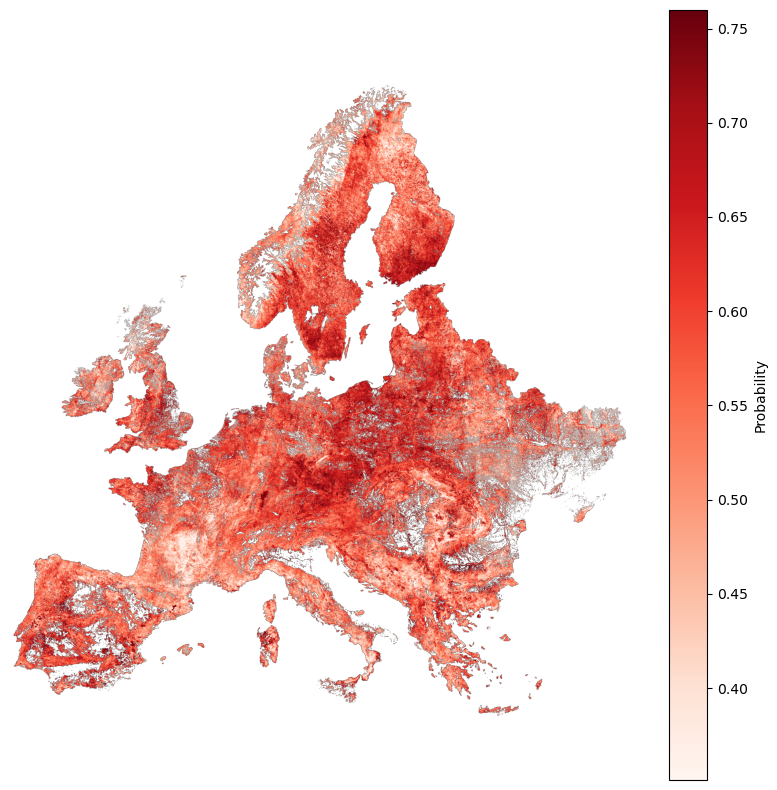

In [10]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif"

with rasterio.open(fp) as src:
    scale = 50
    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average
    )

arr_masked = np.ma.masked_less(arr, 0.1)

valid = arr_masked.compressed()
vmin, vmax = np.percentile(valid, [2, 98])

cmap = plt.cm.Reds.copy()
cmap.set_bad(alpha=0)

out_png = "/mnt/eo/EO4Backcasting/_figs/probability_map_200dpi.png"

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(arr_masked, vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(im, ax=ax, label="Probability")
ax.set_title("")
ax.axis("off")

fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

In [4]:
## Clip disturbances

# Cell 1: Imports
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window

# Cell 2: Paths
pred_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif")
dist_fp = Path("/mnt/eo/EFDA_v211/yod_aligned.tif")

out_fp = pred_fp.parent / "global_model_no_dist.tif"


In [5]:
# Cell 3: Optional quick grid check
with rasterio.open(pred_fp) as pred, rasterio.open(dist_fp) as dist:
    print("Prediction")
    print(pred.crs, pred.transform, pred.width, pred.height)
    print("Disturbance")
    print(dist.crs, dist.transform, dist.width, dist.height)

    same_grid = (
        pred.crs == dist.crs and
        pred.transform == dist.transform and
        pred.width == dist.width and
        pred.height == dist.height
    )

print("Same grid:", same_grid)

Prediction
EPSG:3035 | 30.00, 0.00, 2612197.93|
| 0.00,-30.00, 5565550.42|
| 0.00, 0.00, 1.00| 130000 140000
Disturbance
EPSG:3035 | 30.00, 0.00, 2612197.93|
| 0.00,-30.00, 5565550.42|
| 0.00, 0.00, 1.00| 130000 140000
Same grid: True


In [6]:
# Cell 4: Block-wise masking
# Assumption:
# disturbance pixels are all values > 0
# background / no disturbance is 0
#
# Adjust this line if your disturbance raster uses another coding.

with rasterio.open(pred_fp) as pred, rasterio.open(dist_fp) as dist:
    profile = pred.profile.copy()
    profile.update(
        compress="ZSTD",
        predictor=3,   # good for Float32 output
        tiled=True,
        BIGTIFF="YES"
    )

    pred_nodata = pred.nodata
    if pred_nodata is None:
        pred_nodata = -9999.0
        profile.update(nodata=pred_nodata)

    with rasterio.open(out_fp, "w", **profile) as dst:
        for ji, window in pred.block_windows(1):
            pred_arr = pred.read(1, window=window)
            dist_arr = dist.read(1, window=window)

            # disturbance mask: adjust if needed
            mask_dist = np.isfinite(dist_arr) & (dist_arr > 0)

            out_arr = pred_arr.copy()
            out_arr[mask_dist] = pred_nodata

            dst.write(out_arr, 1, window=window)

print(f"Written to: {out_fp}")

Written to: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif


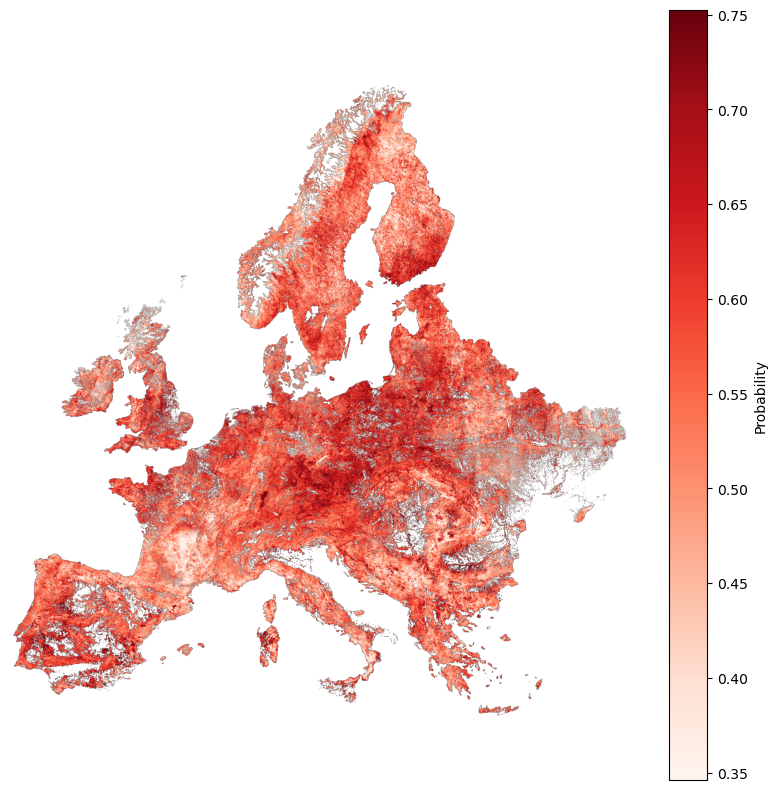

In [12]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

with rasterio.open(fp) as src:
    scale = 50
    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average,
        masked=True
    )

# optional: zusätzlich alles < 0.1 ausmaskieren
arr = np.ma.masked_less(arr, 0.1)

valid = arr.compressed()
vmin, vmax = np.percentile(valid, [2, 98])

cmap = plt.cm.Reds.copy()
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(im, ax=ax, label="Probability")
ax.axis("off")

out_png = "/mnt/eo/EO4Backcasting/_figs/probability_map_cleaned_200dpi.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)

plt.show()

In [1]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent
from rasterio.windows import Window
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Input / output
# ------------------------------------------------------------
fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
out_png = "/mnt/eo/EO4Backcasting/_figs/probability_map_countries_scalebar.png"

# weniger stark reduzieren
scale = 10   # 1 = Originalauflösung, 2 = nahezu Originalauflösung, 5 = etwas leichter

# Werte unter diesem Schwellenwert ausblenden
prob_threshold = 0.1

# Farbskala, z.B. "magma", "viridis", "plasma", "cividis", "inferno"
cmap_name = "viridis"

# ------------------------------------------------------------
# Kleine Hilfsfunktion für Maßstab
# ------------------------------------------------------------
def add_scalebar(ax, length_km=500, location=(0.08, 0.08), linewidth=4):
    """
    Fügt einen einfachen Maßstab hinzu.
    Funktioniert korrekt, wenn das CRS metrisch ist, z.B. EPSG:3035.
    """
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]

    x_start = xlim[0] + location[0] * x_range
    y_start = ylim[0] + location[1] * y_range

    length_m = length_km * 1000
    x_end = x_start + length_m

    ax.plot(
        [x_start, x_end],
        [y_start, y_start],
        color="black",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=10
    )

    ax.text(
        x_start + length_m / 2,
        y_start + 0.025 * y_range,
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        zorder=10
    )

# ------------------------------------------------------------
# Raster lesen
# ------------------------------------------------------------
with rasterio.open(fp) as src:
    print("Raster CRS:", src.crs)
    print("Raster size:", src.width, src.height)
    print("Resolution:", src.res)

    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average if scale > 1 else Resampling.nearest,
        masked=True
    )

    # wichtig: transform an neue Ausgabeauflösung anpassen
    transform = src.transform * src.transform.scale(
        src.width / out_width,
        src.height / out_height
    )

    extent = plotting_extent(arr, transform)

    # Ländergrenzen passend zum Raster-CRS laden
    countries_eur = load_europe_countries(
        target_crs=src.crs,
        clip_mainland=True
    )

# ------------------------------------------------------------
# Werte maskieren und Farbskalierung bestimmen
# ------------------------------------------------------------
arr = np.ma.masked_less(arr, prob_threshold)

valid = arr.compressed()
vmin, vmax = np.percentile(valid, [2, 98])

print("Displayed value range:", vmin, vmax)

# Farbskala vorbereiten
cmap = plt.get_cmap(cmap_name).copy()
cmap.set_bad(alpha=0)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(
    arr,
    extent=extent,
    origin="upper",
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    interpolation="none"
)

# Ländergrenzen darüberlegen
countries_eur.boundary.plot(
    ax=ax,
    linewidth=0.4,
    edgecolor="black",
    alpha=0.8,
    zorder=5
)

# Maßstab hinzufügen
add_scalebar(ax, length_km=500)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Probability")

ax.set_axis_off()

fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Written:", out_png)

Raster CRS: EPSG:3035
Raster size: 130000 140000
Resolution: (30.0, 30.0)


NameError: name 'load_europe_countries' is not defined

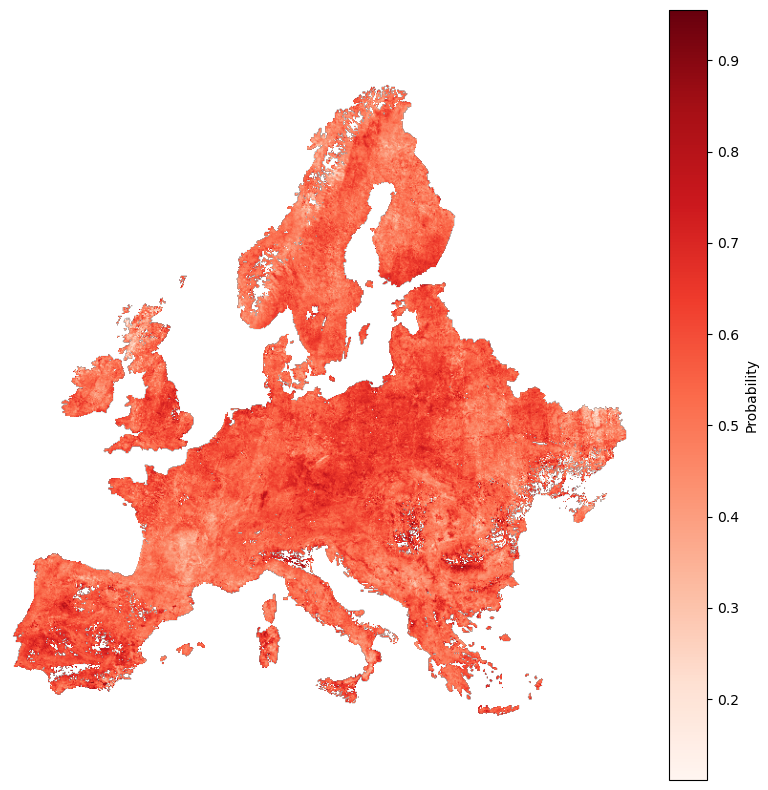

In [2]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

with rasterio.open(fp) as src:
    scale = 200
    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average,
        masked=True
    )

# optional: zusätzlich alles < 0.1 ausmaskieren
arr = np.ma.masked_less(arr, 0.1)

valid = arr.compressed()
vmin, vmax = np.percentile(valid, [0, 100])

cmap = plt.cm.Reds.copy()
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(im, ax=ax, label="Probability")
ax.axis("off")

out_png = "/mnt/eo/EO4Backcasting/_figs/probability_map_cleaned_200dpi.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)

plt.show()

In [13]:
# Compare distribution of rasters

from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

orig_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif")
clean_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif")


In [14]:
def read_valid_values_blockwise(fp, min_prob=None, max_values=None):
    values = []

    with rasterio.open(fp) as src:
        nodata = src.nodata

        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            mask = np.isfinite(arr)
            if nodata is not None:
                mask &= (arr != nodata)

            if min_prob is not None:
                mask &= (arr >= min_prob)

            vals = arr[mask]

            if vals.size > 0:
                values.append(vals)

    if not values:
        return np.array([])

    values = np.concatenate(values)

    if max_values is not None and values.size > max_values:
        rng = np.random.default_rng(42)
        idx = rng.choice(values.size, size=max_values, replace=False)
        values = values[idx]

    return values

In [15]:
orig_vals = read_valid_values_blockwise(orig_fp, max_values=2_000_000)
clean_vals = read_valid_values_blockwise(clean_fp, max_values=2_000_000)

print("Original raster:")
print("  n =", orig_vals.size)
print("  min/max =", orig_vals.min(), orig_vals.max())

print("Cleaned raster:")
print("  n =", clean_vals.size)
print("  min/max =", clean_vals.min(), clean_vals.max())

Original raster:
  n = 2000000
  min/max = 0.024717953 0.97960246
Cleaned raster:
  n = 2000000
  min/max = 0.02520311 0.9835005


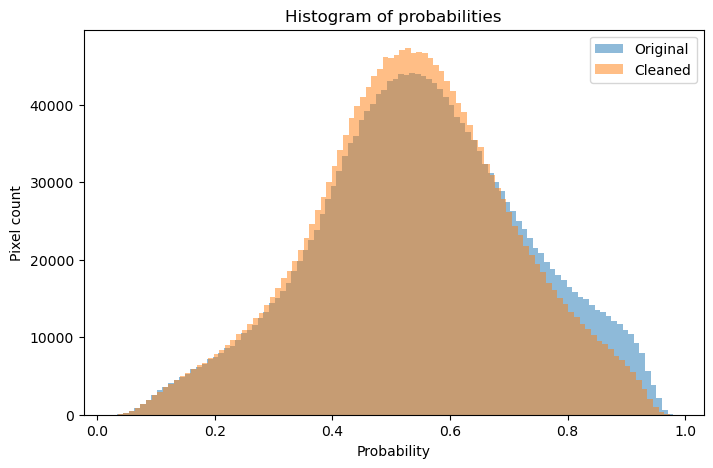

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(orig_vals, bins=100, alpha=0.5, label="Original", density=False)
ax.hist(clean_vals, bins=100, alpha=0.5, label="Cleaned", density=False)

ax.set_xlabel("Probability")
ax.set_ylabel("Pixel count")
ax.set_title("Histogram of probabilities")
ax.legend()

plt.show()

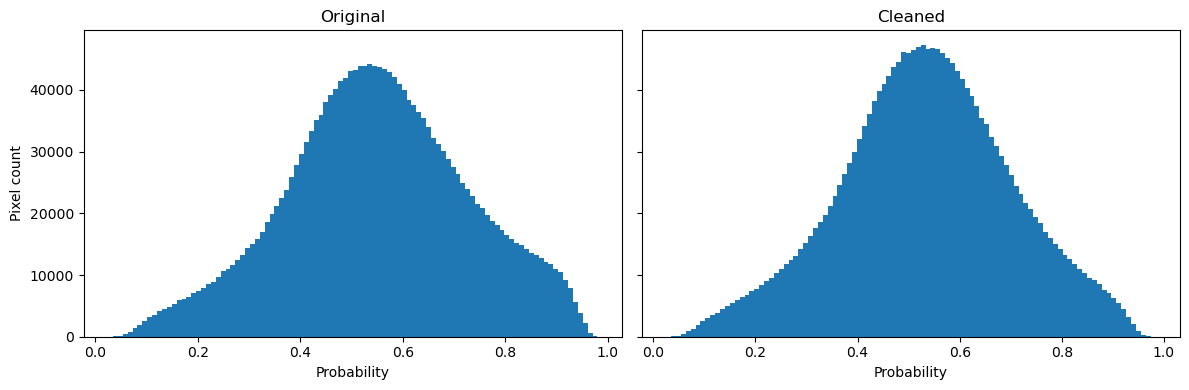

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(orig_vals, bins=100)
axes[0].set_title("Original")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Pixel count")

axes[1].hist(clean_vals, bins=100)
axes[1].set_title("Cleaned")
axes[1].set_xlabel("Probability")

plt.tight_layout()
plt.show()